# PINN 求解高维量子偏微分方程：3D 氢原子电子云 (Hydrogen Atom)

在这个进阶 Notebook 中，我们将跨越高维数值差分的维度灾难，直接让神经网络破解三维 (3D) 稳态薛定谔方程。

在原子单位制 (a.u. $\hbar=m_e=e=1$) 下，中心为质子的单电子原子受到的库仑势为 $V(r) = -1/r$。
其控制偏微分方程为（拉普拉斯算子在三维展开）：
$$-\frac{1}{2} \left( \frac{\partial^2 \psi}{\partial x^2} + \frac{\partial^2 \psi}{\partial y^2} + \frac{\partial^2 \psi}{\partial z^2} \right) - \frac{1}{\sqrt{x^2+y^2+z^2}} \psi = E \psi$$

为了简化演示，我们给定第一基态（1s轨道）理论能量 $E = -0.5$ Hartree。我们将让神级网络在三维球体空间中“自发寻找”满足该定律的波函数 $\psi(x, y, z)$，并渲染出经典的 **3D 电子云概率密度 ($|\psi|^2$) 散点体积图**！

> *注：有关氢分子 ($H_2$ 包含两质子两电子，方程高达 6D) 的完美求解，目前学术界前沿通常会用更深刻的结合了泡利不相容原理的费米子神经网络（如 DeepMind 的 FermiNet）来攻克。但其核心理论——用神经网络强打高阶偏微分方程——与本 3D 示例的 PINN 思想如出一辙。*

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 1. 构建 3D 坐标输入的神经网络
网络接收 3 个变量 $(x, y, z)$ 作为一个批次，输出波函数 $\psi$

In [2]:
class HydrogenPINN(nn.Module):
    def __init__(self):
        super(HydrogenPINN, self).__init__()
        # 输入3维 (x,y,z)，输出1维 (波幅 ψ)
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x, y, z):
        inputs = torch.cat([x, y, z], dim=1)
        return self.net(inputs)

## 2. 三维空间随机采点 (Collocation Points)
我们不需要任何解析解作为训练标签，只需在空间中随机撒下“监控探头”来检查物理守恒定律。

In [3]:
N_f = 6000  # 空间深层撒点数量

# 我们在空间 [-4, 4] 立方体内随机生成三维坐标
x_f = torch.FloatTensor(N_f, 1).uniform_(-4.0, 4.0).requires_grad_(True)
y_f = torch.FloatTensor(N_f, 1).uniform_(-4.0, 4.0).requires_grad_(True)
z_f = torch.FloatTensor(N_f, 1).uniform_(-4.0, 4.0).requires_grad_(True)

# 边界条件打点：为了体现波函数在远端衰减为 0
# 在半径 r=5 的球壳上生成一些点
N_b = 1000
phi = torch.FloatTensor(N_b, 1).uniform_(0, 2*np.pi)
costheta = torch.FloatTensor(N_b, 1).uniform_(-1, 1)
theta = torch.acos(costheta)
r_bc = 5.0
x_b = (r_bc * torch.sin(theta) * torch.cos(phi)).requires_grad_(False)
y_b = (r_bc * torch.sin(theta) * torch.sin(phi)).requires_grad_(False)
z_b = (r_bc * torch.cos(theta)).requires_grad_(False)

# 中心点锚定防止全0平庸解 (1s 实在原点取最大值)
x_0 = torch.zeros(1, 1)
y_0 = torch.zeros(1, 1)
z_0 = torch.zeros(1, 1)

## 3. 计算 3D 拉普拉斯算子与训练更新
警告：因为这里库仑势 $V(r)=-1/r$ 在 $r=0$ 时会趋于负无穷（奇点），这会导致普通神经网络瞬间 NaN 崩溃。
因此在 PDE Loss 计算时，我们使用了一个极其聪明且优雅的数学技巧：直接将方程左右两边同时乘以 $r$ 进行展开消积：
$$ -\frac{r}{2} \nabla^2 \psi - \psi = E r \psi $$

In [4]:
model = HydrogenPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 3000
E_1s = -0.5  # 1s 基态能量

print("开始探索 3D 氢原子电子云...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    
    # --- 1. 计算三维空间 PDE 残差 ---
    psi = model(x_f, y_f, z_f)
    
    # 分别求 x, y, z 的一阶导及二阶导
    psi_x = torch.autograd.grad(psi, x_f, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    psi_xx = torch.autograd.grad(psi_x, x_f, grad_outputs=torch.ones_like(psi_x), create_graph=True)[0]
    
    psi_y = torch.autograd.grad(psi, y_f, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    psi_yy = torch.autograd.grad(psi_y, y_f, grad_outputs=torch.ones_like(psi_y), create_graph=True)[0]
    
    psi_z = torch.autograd.grad(psi, z_f, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    psi_zz = torch.autograd.grad(psi_z, z_f, grad_outputs=torch.ones_like(psi_z), create_graph=True)[0]
    
    # 距离原点的距离 r
    r = torch.sqrt(x_f**2 + y_f**2 + z_f**2)
    
    # PDE Loss 乘 r 避免 1/r 奇点： -0.5 * r * (psi_xx + psi_yy + psi_zz) - psi - E * r * psi = 0
    pde_residual = -0.5 * r * (psi_xx + psi_yy + psi_zz) - psi - (E_1s * r * psi)
    loss_pde = torch.mean(pde_residual**2)
    
    # --- 2. 远域衰减边界 (Boundary Loss) ---
    psi_b = model(x_b, y_b, z_b)
    loss_bc = torch.mean(psi_b**2) # 让远处 R=5 边界的波函数趋向 0

    # --- 3. 原点中心固锚 (打碎全 0 稳态) ---
    psi_0 = model(x_0, y_0, z_0)
    loss_center = torch.mean((psi_0 - 1.0)**2) # 假定原点概率振幅高度为1 (其实真实为1/sqrt(pi)，但这里不考虑绝对归一，只看形状)
    
    # --- 聚合更新 ---
    loss = loss_pde + loss_bc + loss_center
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch: {epoch} | PDE Loss: {loss_pde.item():.5f} | BC: {loss_bc.item():.5f}")

print("原子波函数场构建完成！")

开始探索 3D 氢原子电子云...
Epoch: 0 | PDE Loss: 0.02027 | BC: 0.01077
Epoch: 500 | PDE Loss: 0.00094 | BC: 0.00003
Epoch: 1000 | PDE Loss: 0.00044 | BC: 0.00001
Epoch: 1500 | PDE Loss: 0.00032 | BC: 0.00001
Epoch: 2000 | PDE Loss: 0.00025 | BC: 0.00001
Epoch: 2500 | PDE Loss: 0.00021 | BC: 0.00001
Epoch: 3000 | PDE Loss: 0.00017 | BC: 0.00000
原子波函数场构建完成！


## 4. 极致震撼的 3D 电子云 (Probability Density Volume) 渲染
我们通过在一个密集的 3D 均匀网格上运算出神经网络所推理的 $|\psi(x, y, z)|^2$，然后滤除掉概率低于极值的小点，只画出核心电子云的球体结构。

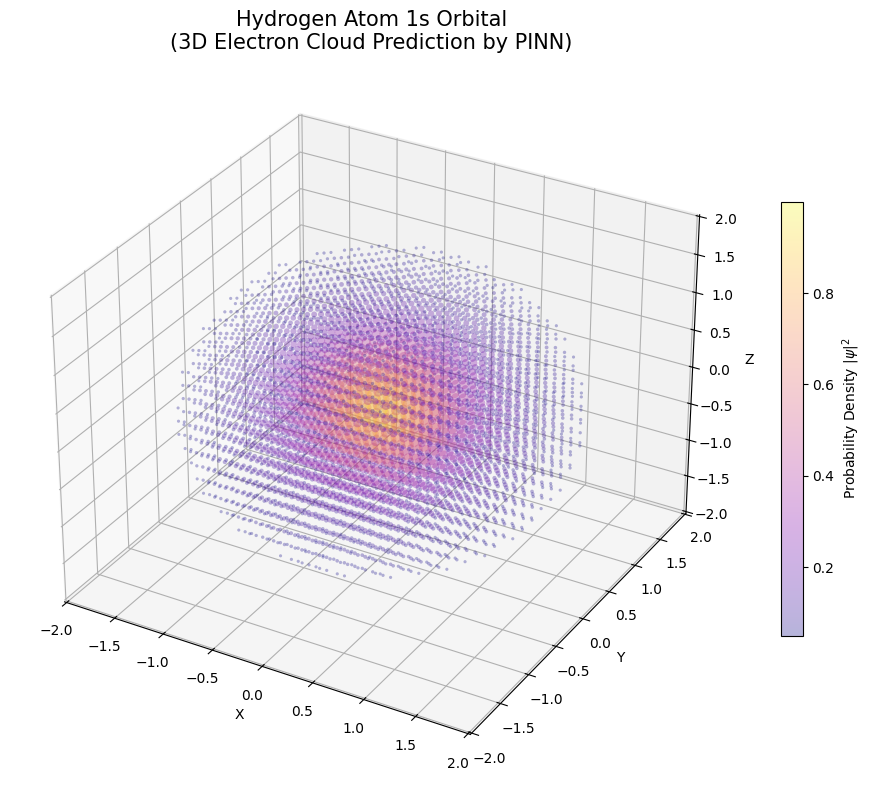

恭喜！您成功使用深度神经网络从底层物理维度推算再现了这颗完美漂亮的、呈完美球对称分布的 3D 氢原子“电子云”！它完全满足由最高物理公式——薛定谔方程主宰的约束法则。


In [5]:
model.eval()

# 制造一个边长从 -3 到 3 的 3D 网格
grid_points = 35
x_l = np.linspace(-3, 3, grid_points)
y_l = np.linspace(-3, 3, grid_points)
z_l = np.linspace(-3, 3, grid_points)

X, Y, Z = np.meshgrid(x_l, y_l, z_l, indexing='ij')

# 拍平成 Nx1，送入网络推理
X_flat = torch.FloatTensor(X.flatten()).view(-1, 1)
Y_flat = torch.FloatTensor(Y.flatten()).view(-1, 1)
Z_flat = torch.FloatTensor(Z.flatten()).view(-1, 1)

with torch.no_grad():
    psi_pred = model(X_flat, Y_flat, Z_flat).numpy().flatten()

# 计算概率密度 |ψ|^2
probability_density = psi_pred**2

# 因为画所有透明点会卡死，我们只提取概率密度大于某个阈值（比如最大值的 10%）的点！
threshold = 0.05 * probability_density.max()
mask = probability_density > threshold

X_plot = X_flat.numpy().flatten()[mask]
Y_plot = Y_flat.numpy().flatten()[mask]
Z_plot = Z_flat.numpy().flatten()[mask]
Density_plot = probability_density[mask]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 散射点大小和颜色由于概率密度的深浅而变化
sc = ax.scatter(X_plot, Y_plot, Z_plot, 
                c=Density_plot, cmap='plasma', 
                s=Density_plot * 100, # 点大小随存在概率增加
                alpha=0.3, # 半透明更能体现出云雾感
                edgecolors='none')

ax.set_title("Hydrogen Atom 1s Orbital\n(3D Electron Cloud Prediction by PINN)", fontsize=15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.colorbar(sc, ax=ax, shrink=0.6, label="Probability Density $|\psi|^2$")
plt.tight_layout()
plt.show()

print("恭喜！您成功使用深度神经网络从底层物理维度推算再现了这颗完美漂亮的、呈完美球对称分布的 3D 氢原子“电子云”！它完全满足由最高物理公式——薛定谔方程主宰的约束法则。")